In [1]:
from typing import TypedDict
from langgraph.graph import  StateGraph,START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os 

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [ ]:
llm = ChatGroq(model="qwen/qwen3.6-27b")  # Initialize the Groq LLM

In [5]:
response = llm.invoke("Hello, how are you?")
response

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hello, how are you?"\n   - This is a standard greeting and polite inquiry about my state.\n\n2.  **Identify Key Components:**\n   - Greeting: "Hello"\n   - Question: "how are you?"\n   - Tone: Casual, friendly\n\n3.  **Determine Appropriate Response:**\n   - Acknowledge the greeting\n   - Respond to the question politely\n   - Keep it concise and friendly\n   - Offer assistance (standard AI behavior)\n   - Maintain natural, conversational tone\n\n4.  **Draft Response (Mental):**\n   Hello! I\'m doing well, thank you for asking. How can I help you today?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional\n   - Check accuracy: I don\'t have feelings, but it\'s standard to respond politely\n   - Keep it open-ended to encourage conversation\n   - Final version matches the draft\n\n6.  **Output Generation:** (Proceeds to output)✅\n</think>\n\nHello! I\'m doing well, t

In [6]:
class LLMState(TypedDict):
    title : str
    outline : str
    content: str

In [7]:
graph  = StateGraph(LLMState)

In [8]:
def generate_outline(state: LLMState) -> LLMState:
    
    title = state['title']
    
    prompt = f" Generate an outline for a blog post with the title {title}"
    
    response = llm.invoke(prompt)
    
    state['outline'] = response
    
    return state 

In [9]:
def generate_content(state: LLMState) -> LLMState:
    
    title = state['title']
    outline = state['outline']
    
    prompt = f" Generate content for a blog post on topic {title} with the outline {outline}"
    
    response = llm.invoke(prompt)
    
    state['content'] = response
    
    
    return state 

In [10]:
graph.add_node("Outline Generator", generate_outline)
graph.add_node("Content Generator", generate_content)

In [11]:
graph.add_edge(START, "Outline Generator")
graph.add_edge("Outline Generator", "Content Generator")
graph.add_edge("Content Generator", END)

workflow = graph.compile()

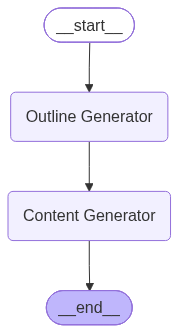

In [12]:
workflow 

In [13]:
initial_state = LLMState(title="The Future of AI in Healthcare")

In [14]:
final_state = workflow.invoke(initial_state)

In [ ]:
import printfy
print(final_state['content'])


content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Topic:** The Future of AI in Healthcare\n   - **Input:** The user provided an outline (which looks like it was generated by an AI in a previous turn, but they want me to "Generate content for a blog post on topic The Future of AI in Healthcare with the outline content=\'...\'"). Wait, the prompt says `with the outline content=\'\\nHere\\\'s a thinking process:...` It seems the user pasted an AI\'s internal thought process/outline generation as the outline itself. Actually, the prompt is: `Generate content for a blog post on topic The Future of AI in Healthcare with the outline content=\'\\n<think>\\nHere\'s a thinking process:\\n\\n1.  **Analyze User Input:**...` This looks like a copy-paste error where they included the AI\'s reasoning/output from a previous prompt. But the core request is clear: Write a blog post based on the provided outline about "The Future of AI in Healthcare".\n   - I need to 